In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sriramr/fruits-fresh-and-rotten-for-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/


In [2]:
import os

print("\n📂 Subfolders inside main dataset directory:")
print(os.listdir(path))



📂 Subfolders inside main dataset directory:
['dataset']


In [3]:
subdirs = os.listdir(path)

if "dataset" in subdirs:
    data_dir = os.path.join(path, "dataset")
elif "fruits-fresh-and-rotten-for-classification" in subdirs:
    data_dir = os.path.join(path, "fruits-fresh-and-rotten-for-classification")
else:
    data_dir = path

print("\n✅ Final data directory set to:", data_dir)
print("📂 Subfolders inside data_dir:", os.listdir(data_dir))



✅ Final data directory set to: /kaggle/input/dataset
📂 Subfolders inside data_dir: ['dataset', 'test', 'train']


In [4]:
if os.path.exists(os.path.join(data_dir, "train")):
    train_dir = os.path.join(data_dir, "train")
    test_dir = os.path.join(data_dir, "test")
elif os.path.exists(os.path.join(data_dir, "dataset", "train")):
    train_dir = os.path.join(data_dir, "dataset", "train")
    test_dir = os.path.join(data_dir, "dataset", "test")
else:
    
    train_dir = data_dir
    test_dir = data_dir

print("\n Training directory:", train_dir)
print(" Testing directory:", test_dir)



 Training directory: /kaggle/input/dataset/train
 Testing directory: /kaggle/input/dataset/test


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1 
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

print("\n Data loaded successfully!")


2025-12-13 08:27:31.432203: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765614451.623127      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765614451.681351      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Found 9813 images belonging to 6 classes.
Found 1088 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.

 Data loaded successfully!


🧾 Class labels: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


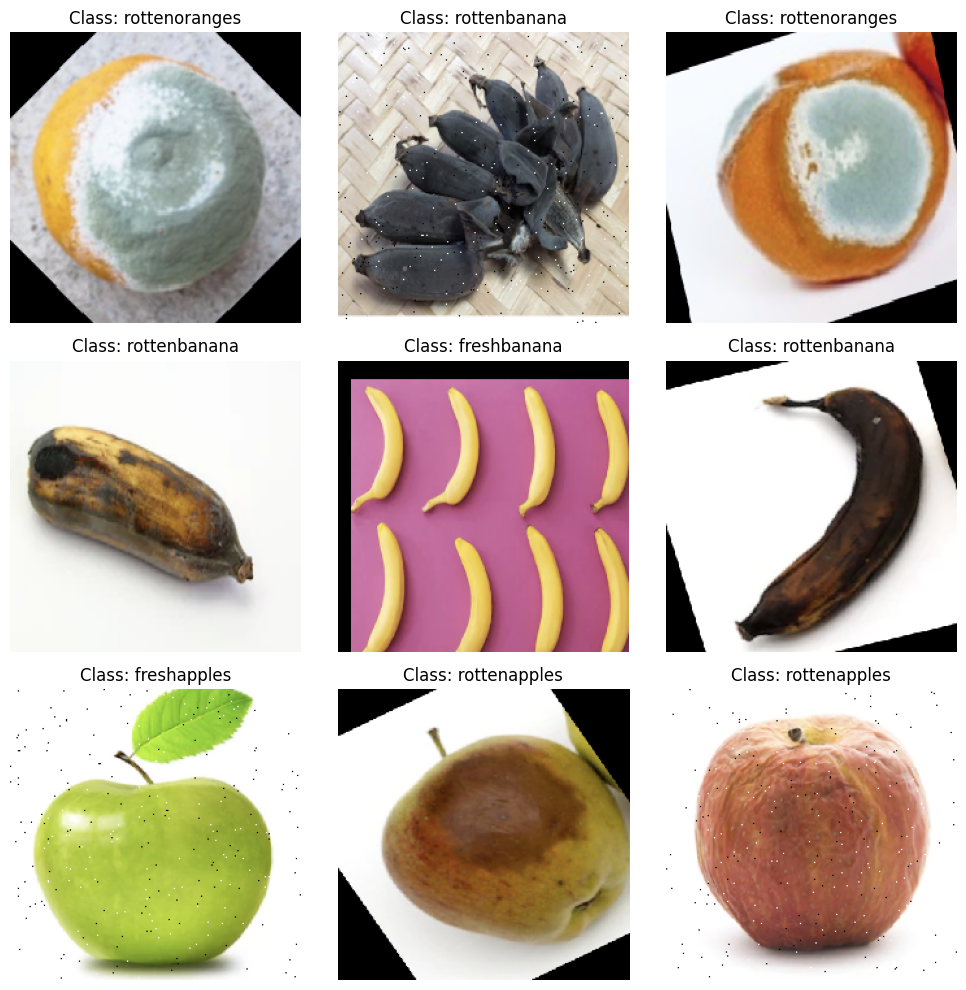

In [6]:
import matplotlib.pyplot as plt
import numpy as np



class_names = list(train_data.class_indices.keys())
print("🧾 Class labels:", class_names)


plt.figure(figsize=(10, 10))

for i in range(9):

    img, label = next(train_data)
    random_index = np.random.randint(0, img.shape[0])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img[random_index])
    plt.title(f"Class: {class_names[np.argmax(label[random_index])]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [7]:
import os, random, cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

In [8]:
# ✅ Get the already-correct path from your train_data object
train_dir = train_data.directory

In [9]:
# pick one random class and three random images
sample_class = random.choice(os.listdir(train_dir))
sample_folder = os.path.join(train_dir, sample_class)
sample_images = random.sample(os.listdir(sample_folder), 3)

In [10]:
print(f"📁 Sample class: {sample_class}")
print(f"🖼️ Sample images: {sample_images}")

📁 Sample class: freshbanana
🖼️ Sample images: ['rotated_by_60_Screen Shot 2018-06-12 at 9.39.00 PM.png', 'rotated_by_30_Screen Shot 2018-06-12 at 10.00.49 PM.png', 'saltandpepper_Screen Shot 2018-06-12 at 9.53.46 PM.png']


In [11]:
# --- preprocessing function 
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

   
    img = cv2.GaussianBlur(img, (3, 3), 0)

 
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

 
    return img / 255.0, enhanced / 255.0

In [12]:
#Step 4: PSNR and SSIM
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

for img_name in sample_images:
    p = os.path.join(sample_folder, img_name)
    orig, proc = preprocess_image(p)
    print(img_name,
          "PSNR:", psnr(orig, proc),
          "SSIM:",
          ssim((orig*255).astype('uint8'),
               (proc*255).astype('uint8'),
               channel_axis=2))


rotated_by_60_Screen Shot 2018-06-12 at 9.39.00 PM.png PSNR: 23.665241848881248 SSIM: 0.7539629606520927
rotated_by_30_Screen Shot 2018-06-12 at 10.00.49 PM.png PSNR: 23.879248849032358 SSIM: 0.8165197924474091
saltandpepper_Screen Shot 2018-06-12 at 9.53.46 PM.png PSNR: 26.76290955915973 SSIM: 0.9377080469004498


In [13]:
#  Step 5: Train / Val / Test Split (80-10-10) --------------------


import os
import glob
from sklearn.model_selection import train_test_split


all_images = []
all_labels = []

class_names = os.listdir(train_dir)  

for cls in class_names:
    class_path = os.path.join(train_dir, cls)
    for img_path in glob.glob(os.path.join(class_path, "*")):
        all_images.append(img_path)
        all_labels.append(cls)


X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels,
    test_size=0.20,       
    stratify=all_labels,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,         
    stratify=y_temp,
    random_state=42
)

print("Total images:", len(all_images))
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))


Total images: 10901
Train: 8720
Validation: 1090
Test: 1091


In [14]:
# -------------------- Step 6: Data Augmentation --------------------
# Generate exactly 2 augmented versions per image.

from tensorflow.keras.preprocessing.image import ImageDataGenerator

augment_gen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_gen = ImageDataGenerator()



In [15]:
#Step 6 – Part 2: Generate Exactly 2 Augmented Versions per Training Image
import cv2
import numpy as np

augmented_images = []
augmented_labels = []

for idx, img_path in enumerate(X_train):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = np.expand_dims(img, axis=0)

    # Create exactly 2 augmented versions
    for _ in range(2):
        aug_img = next(augment_gen.flow(img, batch_size=1))[0]
        augmented_images.append(aug_img)
        augmented_labels.append(y_train[idx])

print("Original training images:", len(X_train))
print("Augmented images created:", len(augmented_images))
print("Final total training samples:", len(X_train) + len(augmented_images))


Original training images: 8720
Augmented images created: 17440
Final total training samples: 26160


In [16]:
# Step 7 : VGG16 
import tensorflow as tf
import gc
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import VGG16
from tensorflow.keras import mixed_precision

tf.keras.backend.clear_session()
gc.collect()
mixed_precision.set_global_policy('mixed_float16')

train_data.batch_size = 8
val_data.batch_size = 8

MODEL_NAME = "vgg16_safe"
OUTPUT_DIR = "/content/ensemble_models"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE = (224,224)

def build_model():
    base = VGG16(weights="imagenet",
                 include_top=False,
                 input_shape=(224,224,3))  
    for layer in base.layers:
        layer.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base.output) 
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(train_data.num_classes, activation="softmax", dtype='float32')(x)
    
    model = models.Model(inputs=base.input, outputs=out)
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model()
model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint(f"{OUTPUT_DIR}/{MODEL_NAME}_best.keras", save_best_only=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    callbacks=callbacks,
    verbose=1
)

model.save(f"{OUTPUT_DIR}/{MODEL_NAME}_final.keras")

# ============================================================
# EVALUATE AND DISPLAY ALL ACCURACIES
# ============================================================

print("\n" + "="*70)
print("📊 EVALUATING VGG16 MODEL - ALL ACCURACIES")
print("="*70)

# Load best model
best_model = tf.keras.models.load_model(f"{OUTPUT_DIR}/{MODEL_NAME}_best.keras")

# Evaluate on Training Set
print("\n🔹 Evaluating on TRAINING set...")
train_loss, train_accuracy = best_model.evaluate(train_data, verbose=0)

# Evaluate on Validation Set
print("🔹 Evaluating on VALIDATION set...")
val_loss, val_accuracy = best_model.evaluate(val_data, verbose=0)

# Evaluate on Test Set
print("🔹 Evaluating on TEST set...")
test_loss, test_accuracy = best_model.evaluate(test_data, verbose=0)

# Display Summary Table
print("\n" + "="*70)
print(f"{'Dataset':<20} {'Accuracy':<20} {'Loss':<20}")
print("="*70)
print(f"{'Training':<20} {train_accuracy*100:>6.2f}%{'':<12} {train_loss:>8.4f}")
print(f"{'Validation':<20} {val_accuracy*100:>6.2f}%{'':<12} {val_loss:>8.4f}")
print(f"{'Test':<20} {test_accuracy*100:>6.2f}%{'':<12} {test_loss:>8.4f}")
print("="*70)

# Check for overfitting
print("\n📈 Performance Analysis:")
if train_accuracy - test_accuracy > 0.05:
    print(f"   ⚠️  Overfitting detected: Train-Test gap = {(train_accuracy - test_accuracy)*100:.2f}%")
elif test_accuracy >= val_accuracy:
    print(f"   ✅ Good generalization: Test accuracy matches/exceeds validation")
else:
    print(f"   ✅ Model is well-generalized")

print(f"\n✅ VGG16 TRAINING & EVALUATION COMPLETED")
print("="*70)

I0000 00:00:1765614710.016420      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast (Cast)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_1 (Cast)                   │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 14,781,126 (56.39 MB)

...

Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1765614713.629636     135 service.cc:148] XLA service 0x7b637000e5d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765614713.630576     135 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765614714.039024     135 cuda_dnn.cc:529] Loaded cuDNN version 90300


   5/1227 ━━━━━━━━━━━━━━━━━━━━ 49s 41ms/step - accuracy: 0.1517 - loss: 2.2305

I0000 00:00:1765614718.604150     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1227/1227 ━━━━━━━━━━━━━━━━━━━━ 67s 49ms/step - accuracy: 0.5824 - loss: 1.2253 - val_accuracy: 0.9090 - val_loss: 0.4652
Epoch 2/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.8508 - loss: 0.5604 - val_accuracy: 0.9421 - val_loss: 0.3527
Epoch 3/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.8788 - loss: 0.4793 - val_accuracy: 0.9090 - val_loss: 0.3610
Epoch 4/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 53s 43ms/step - accuracy: 0.8851 - loss: 0.4475 - val_accuracy: 0.9173 - val_loss: 0.3438
Epoch 5/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 52s 43ms/step - accuracy: 0.8929 - loss: 0.4218 - val_accuracy: 0.9577 - val_loss: 0.2752
Epoch 6/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 51s 42ms/step - accuracy: 0.8903 - loss: 0.4162 - val_accuracy: 0.9458 - val_loss: 0.2854
Epoch 7/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.8949 - loss: 0.4090 - val_accuracy: 0.9504 - val_loss: 0.2839
Epoch 8/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 50s 41ms/step - accuracy: 0.9065 - loss: 0.38

In [17]:
# Step 7 : Train transfer learning model — ResNet50
import tensorflow as tf
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import ResNet50
import os, gc

tf.keras.backend.clear_session()
gc.collect()

MODEL_NAME = "resnet50"
OUTPUT_DIR = "/content/ensemble_models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def build_model():
    base = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
    for layer in base.layers:
        layer.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(train_data.num_classes, activation="softmax")(x)
    
    model = models.Model(inputs=base.input, outputs=outputs)
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model = build_model()
model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint(f"{OUTPUT_DIR}/{MODEL_NAME}_best.keras", save_best_only=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

model.save(f"{OUTPUT_DIR}/{MODEL_NAME}_final.keras")

# ============================================================
# EVALUATE AND DISPLAY ALL ACCURACIES
# ============================================================

print("\n" + "="*70)
print("📊 EVALUATING RESNET50 MODEL - ALL ACCURACIES")
print("="*70)

# Load best model
best_model = tf.keras.models.load_model(f"{OUTPUT_DIR}/{MODEL_NAME}_best.keras")

# Evaluate on Training Set
print("\n🔹 Evaluating on TRAINING set...")
train_loss, train_accuracy = best_model.evaluate(train_data, verbose=0)

# Evaluate on Validation Set
print("🔹 Evaluating on VALIDATION set...")
val_loss, val_accuracy = best_model.evaluate(val_data, verbose=0)

# Evaluate on Test Set
print("🔹 Evaluating on TEST set...")
test_loss, test_accuracy = best_model.evaluate(test_data, verbose=0)

# Display Summary Table
print("\n" + "="*70)
print(f"{'Dataset':<20} {'Accuracy':<20} {'Loss':<20}")
print("="*70)
print(f"{'Training':<20} {train_accuracy*100:>6.2f}%{'':<12} {train_loss:>8.4f}")
print(f"{'Validation':<20} {val_accuracy*100:>6.2f}%{'':<12} {val_loss:>8.4f}")
print(f"{'Test':<20} {test_accuracy*100:>6.2f}%{'':<12} {test_loss:>8.4f}")
print("="*70)

# Check for overfitting
print("\n📈 Performance Analysis:")
if train_accuracy - test_accuracy > 0.05:
    print(f"   ⚠️  Overfitting detected: Train-Test gap = {(train_accuracy - test_accuracy)*100:.2f}%")
elif test_accuracy >= val_accuracy:
    print(f"   ✅ Good generalization: Test accuracy matches/exceeds validation")
else:
    print(f"   ✅ Model is well-generalized")

print(f"\n✅ RESNET50 TRAINING & EVALUATION COMPLETED")
print("="*70)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,758 (90.98 MB)

 Trainable params: 263,046 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 68s 47ms/step - accuracy: 0.2714 - loss: 1.9839 - val_accuracy: 0.2978 - val_loss: 1.6675
Epoch 2/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 51s 42ms/step - accuracy: 0.3381 - loss: 1.6237 - val_accuracy: 0.3631 - val_loss: 1.5708
Epoch 3/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 49s 40ms/step - accuracy: 0.3502 - loss: 1.5907 - val_accuracy: 0.3649 - val_loss: 1.5778
Epoch 4/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 50s 41ms/step - accuracy: 0.3380 - loss: 1.5992 - val_accuracy: 0.3410 - val_loss: 1.5912
Epoch 5/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.3473 - loss: 1.5785 - val_accuracy: 0.3318 - val_loss: 1.6112
Epoch 6/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 49s 40ms/step - accuracy: 0.3605 - loss: 1.5830 - val_accuracy: 0.3557 - val_loss: 1.5904
Epoch 7/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 50s 41ms/step - accuracy: 0.3626 - loss: 1.5682 - val_accuracy: 0.3621 - val_loss: 1.5438
Epoch 8/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 51s 42ms/step - accuracy: 0.3603 -

In [18]:
# ================== Step 7 : EfficientNetB0 ==================
import tensorflow as tf
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
import os, gc

tf.keras.backend.clear_session()
gc.collect()

MODEL_NAME = "efficientnetb0"
OUTPUT_DIR = "/content/ensemble_models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def build_model():
    base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))
    for layer in base.layers:
        layer.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(train_data.num_classes, activation="softmax")(x)
    
    model = models.Model(inputs=base.input, outputs=outputs)
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model = build_model()
model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint(f"{OUTPUT_DIR}/{MODEL_NAME}_best.keras", save_best_only=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

model.save(f"{OUTPUT_DIR}/{MODEL_NAME}_final.keras")

# ============================================================
# EVALUATE AND DISPLAY ALL ACCURACIES
# ============================================================

print("\n" + "="*70)
print("📊 EVALUATING EFFICIENTNETB0 MODEL - ALL ACCURACIES")
print("="*70)

# Load best model
best_model = tf.keras.models.load_model(f"{OUTPUT_DIR}/{MODEL_NAME}_best.keras")

# Evaluate on Training Set
print("\n🔹 Evaluating on TRAINING set...")
train_loss, train_accuracy = best_model.evaluate(train_data, verbose=0)

# Evaluate on Validation Set
print("🔹 Evaluating on VALIDATION set...")
val_loss, val_accuracy = best_model.evaluate(val_data, verbose=0)

# Evaluate on Test Set
print("🔹 Evaluating on TEST set...")
test_loss, test_accuracy = best_model.evaluate(test_data, verbose=0)

# Display Summary Table
print("\n" + "="*70)
print(f"{'Dataset':<20} {'Accuracy':<20} {'Loss':<20}")
print("="*70)
print(f"{'Training':<20} {train_accuracy*100:>6.2f}%{'':<12} {train_loss:>8.4f}")
print(f"{'Validation':<20} {val_accuracy*100:>6.2f}%{'':<12} {val_loss:>8.4f}")
print(f"{'Test':<20} {test_accuracy*100:>6.2f}%{'':<12} {test_loss:>8.4f}")
print("="*70)

# Check for overfitting
print("\n📈 Performance Analysis:")
if train_accuracy - test_accuracy > 0.05:
    print(f"   ⚠️  Overfitting detected: Train-Test gap = {(train_accuracy - test_accuracy)*100:.2f}%")
elif test_accuracy >= val_accuracy:
    print(f"   ✅ Good generalization: Test accuracy matches/exceeds validation")
else:
    print(f"   ✅ Model is well-generalized")

print(f"\n✅ EFFICIENTNETB0 TRAINING & EVALUATION COMPLETED")
print("="*70)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 85s 54ms/step - accuracy: 0.2033 - loss: 2.1902 - val_accuracy: 0.2151 - val_loss: 1.7762
Epoch 2/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.2130 - loss: 1.7778 - val_accuracy: 0.2151 - val_loss: 1.7753
Epoch 3/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.2129 - loss: 1.7755 - val_accuracy: 0.2151 - val_loss: 1.7749
Epoch 4/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 54s 44ms/step - accuracy: 0.2114 - loss: 1.7756 - val_accuracy: 0.2151 - val_loss: 1.7754
Epoch 5/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 54s 44ms/step - accuracy: 0.2167 - loss: 1.7741 - val_accuracy: 0.2151 - val_loss: 1.7749
Epoch 6/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 54s 44ms/step - accuracy: 0.2189 - loss: 1.7723 - val_accuracy: 0.2151 - val_loss: 1.7749
Epoch 7/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 53s 44ms/step - accuracy: 0.2155 - loss: 1.7769 - val_accuracy: 0.2151 - val_loss: 1.7749
Epoch 8/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 53s 43ms/step - accuracy: 0.2147 -

In [19]:
# ================== Step 7 : DenseNet121 ==================
import tensorflow as tf
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import DenseNet121
import os, gc

tf.keras.backend.clear_session()
gc.collect()

MODEL_NAME = "densenet121"
OUTPUT_DIR = "/content/ensemble_models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def build_model():
    base = DenseNet121(weights="imagenet", include_top=False, input_shape=(224,224,3))
    for layer in base.layers:
        layer.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(train_data.num_classes, activation="softmax")(x)
    
    model = models.Model(inputs=base.input, outputs=outputs)
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy", 
        metrics=["accuracy"]
    )
    return model

model = build_model()
model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint(f"{OUTPUT_DIR}/{MODEL_NAME}_best.keras", save_best_only=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

model.save(f"{OUTPUT_DIR}/{MODEL_NAME}_final.keras")

# ============================================================
# EVALUATE AND DISPLAY ALL ACCURACIES
# ============================================================

print("\n" + "="*70)
print("📊 EVALUATING DENSENET121 MODEL - ALL ACCURACIES")
print("="*70)

# Load best model
best_model = tf.keras.models.load_model(f"{OUTPUT_DIR}/{MODEL_NAME}_best.keras")

# Evaluate on Training Set
print("\n🔹 Evaluating on TRAINING set...")
train_loss, train_accuracy = best_model.evaluate(train_data, verbose=0)

# Evaluate on Validation Set
print("🔹 Evaluating on VALIDATION set...")
val_loss, val_accuracy = best_model.evaluate(val_data, verbose=0)

# Evaluate on Test Set
print("🔹 Evaluating on TEST set...")
test_loss, test_accuracy = best_model.evaluate(test_data, verbose=0)

# Display Summary Table
print("\n" + "="*70)
print(f"{'Dataset':<20} {'Accuracy':<20} {'Loss':<20}")
print("="*70)
print(f"{'Training':<20} {train_accuracy*100:>6.2f}%{'':<12} {train_loss:>8.4f}")
print(f"{'Validation':<20} {val_accuracy*100:>6.2f}%{'':<12} {val_loss:>8.4f}")
print(f"{'Test':<20} {test_accuracy*100:>6.2f}%{'':<12} {test_loss:>8.4f}")
print("="*70)

# Check for overfitting
print("\n📈 Performance Analysis:")
if train_accuracy - test_accuracy > 0.05:
    print(f"   ⚠️  Overfitting detected: Train-Test gap = {(train_accuracy - test_accuracy)*100:.2f}%")
elif test_accuracy >= val_accuracy:
    print(f"   ✅ Good generalization: Test accuracy matches/exceeds validation")
else:
    print(f"   ✅ Model is well-generalized")

print(f"\n✅ DENSENET121 TRAINING & EVALUATION COMPLETED")
print("="*70)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,169,478 (27.35 MB)

 Trainable params: 131,974 (515.52 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 97s 60ms/step - accuracy: 0.8218 - loss: 1.2186 - val_accuracy: 0.9789 - val_loss: 0.2637
Epoch 2/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 53s 44ms/step - accuracy: 0.9412 - loss: 0.3435 - val_accuracy: 0.9881 - val_loss: 0.2170
Epoch 3/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 52s 43ms/step - accuracy: 0.9449 - loss: 0.3204 - val_accuracy: 0.9890 - val_loss: 0.2145
Epoch 4/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 53s 43ms/step - accuracy: 0.9398 - loss: 0.3221 - val_accuracy: 0.9807 - val_loss: 0.2110
Epoch 5/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 53s 43ms/step - accuracy: 0.9376 - loss: 0.3284 - val_accuracy: 0.9890 - val_loss: 0.1923
Epoch 6/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 54s 44ms/step - accuracy: 0.9395 - loss: 0.3044 - val_accuracy: 0.9926 - val_loss: 0.1904
Epoch 7/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 52s 43ms/step - accuracy: 0.9436 - loss: 0.2997 - val_accuracy: 0.9899 - val_loss: 0.1876
Epoch 8/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.9385 -

In [20]:
# -------------------------# Step 8: ATTENTION BLOCKS -------------------------

import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, Dense, GlobalAveragePooling2D, GlobalMaxPooling2D, Reshape, Multiply, Add, Concatenate

# 1️⃣ CBAM (Convolutional Block Attention Module)
def cbam_block(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    # Channel Attention
    avg_pool = GlobalAveragePooling2D()(input_feature)
    max_pool = GlobalMaxPooling2D()(input_feature)

    dense1 = Dense(channel // ratio, activation='relu')
    dense2 = Dense(channel)

    avg_out = dense2(dense1(avg_pool))
    max_out = dense2(dense1(max_pool))
    channel_attention = tf.nn.sigmoid(avg_out + max_out)

    channel_refined = Multiply()([input_feature, channel_attention[:, None, None, :]])

    # Spatial Attention
    avg_spatial = tf.reduce_mean(channel_refined, axis=-1, keepdims=True)
    max_spatial = tf.reduce_max(channel_refined, axis=-1, keepdims=True)
    concat = Concatenate(axis=-1)([avg_spatial, max_spatial])

    spatial_attention = Conv2D(1, kernel_size=7, padding="same", activation="sigmoid")(concat)
    refined_feature = Multiply()([channel_refined, spatial_attention])

    return refined_feature


# 2️⃣ Self-Attention
def self_attention(inputs):
    f = Conv2D(64, 1)(inputs)
    g = Conv2D(64, 1)(inputs)
    h = Conv2D(64, 1)(inputs)

    attention = tf.matmul(tf.reshape(f, (-1, f.shape[1] * f.shape[2], 64)),
                          tf.reshape(g, (-1, g.shape[1] * g.shape[2], 64)),
                          transpose_b=True)

    attention = tf.nn.softmax(attention)

    out = tf.matmul(attention,
                    tf.reshape(h, (-1, h.shape[1] * h.shape[2], 64)))

    out = tf.reshape(out, (-1, inputs.shape[1], inputs.shape[2], 64))
    out = Conv2D(inputs.shape[-1], 1)(out)

    return Add()([inputs, out])


# 3️⃣ Multi-Head Self Attention (simple)
def mhsa(inputs, num_heads=4):
    attn = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=inputs.shape[-1])(inputs, inputs)
    return attn


In [21]:
# ------------------------- MODEL WITH ATTENTION( Build Model WITH Attention) -------------------------

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input

def build_model_with_attention():
    base = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
    base.trainable = False

    x = base.output

    # Add attention blocks (choose any combination)
    x = cbam_block(x)
    x = self_attention(x)
    # x = mhsa(x)  # uncomment if you want MHSA

    x = Flatten()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    out = Dense(6, activation="softmax")(x)

    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model


In [22]:
# ------------------------- BASELINE (NO attention) -------------------------
def build_model_without_attention():
    base = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
    base.trainable = False
    x = Flatten()(base.output)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    out = Dense(train_data.num_classes, activation="softmax")(x)  # Dynamic classes
    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [23]:
# ------------------------- TRAIN BOTH MODELS -------------------------
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

OUTPUT_DIR = "/content/ensemble_models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train Baseline Model
print("\n🔵 Training Base Model (No Attention)...")
baseline = build_model_without_attention()
baseline_checkpoint = ModelCheckpoint(f"{OUTPUT_DIR}/baseline_vgg16_best.keras", save_best_only=True)
baseline.fit(train_data, validation_data=val_data, epochs=40, callbacks=[early_stop, baseline_checkpoint])

# Evaluate Baseline
print("\n" + "="*70)
print("📊 BASELINE MODEL - ALL ACCURACIES")
print("="*70)
train_loss, train_acc = baseline.evaluate(train_data, verbose=0)
val_loss, val_acc = baseline.evaluate(val_data, verbose=0)
test_loss, test_acc = baseline.evaluate(test_data, verbose=0)

print(f"{'Dataset':<20} {'Accuracy':<20} {'Loss':<20}")
print("="*70)
print(f"{'Training':<20} {train_acc*100:>6.2f}%{'':<12} {train_loss:>8.4f}")
print(f"{'Validation':<20} {val_acc*100:>6.2f}%{'':<12} {val_loss:>8.4f}")
print(f"{'Test':<20} {test_acc*100:>6.2f}%{'':<12} {test_loss:>8.4f}")
print("="*70)

# Train Attention Model
print("\n🟢 Training Attention Model...")
attention_model = build_model_with_attention()
attention_checkpoint = ModelCheckpoint(f"{OUTPUT_DIR}/attention_vgg16_best.keras", save_best_only=True)
attention_model.fit(train_data, validation_data=val_data, epochs=40, callbacks=[early_stop, attention_checkpoint])

# Evaluate Attention Model
print("\n" + "="*70)
print("📊 ATTENTION MODEL - ALL ACCURACIES")
print("="*70)
train_loss, train_acc = attention_model.evaluate(train_data, verbose=0)
val_loss, val_acc = attention_model.evaluate(val_data, verbose=0)
test_loss, test_acc = attention_model.evaluate(test_data, verbose=0)

print(f"{'Dataset':<20} {'Accuracy':<20} {'Loss':<20}")
print("="*70)
print(f"{'Training':<20} {train_acc*100:>6.2f}%{'':<12} {train_loss:>8.4f}")
print(f"{'Validation':<20} {val_acc*100:>6.2f}%{'':<12} {val_loss:>8.4f}")
print(f"{'Test':<20} {test_acc*100:>6.2f}%{'':<12} {test_loss:>8.4f}")
print("="*70)

print("\n✅ BOTH MODELS TRAINING & EVALUATION COMPLETED")


🔵 Training Base Model (No Attention)...
Epoch 1/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 59s 44ms/step - accuracy: 0.6348 - loss: 1.3091 - val_accuracy: 0.9384 - val_loss: 0.2922
Epoch 2/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 50s 41ms/step - accuracy: 0.8127 - loss: 0.4642 - val_accuracy: 0.9605 - val_loss: 0.1452
Epoch 3/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.8413 - loss: 0.3825 - val_accuracy: 0.9494 - val_loss: 0.1178
Epoch 4/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 50s 41ms/step - accuracy: 0.8562 - loss: 0.3318 - val_accuracy: 0.9733 - val_loss: 0.0657
Epoch 5/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 49s 40ms/step - accuracy: 0.8608 - loss: 0.3141 - val_accuracy: 0.9835 - val_loss: 0.0421
Epoch 6/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.8737 - loss: 0.3012 - val_accuracy: 0.9890 - val_loss: 0.0373
Epoch 7/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 53s 43ms/step - accuracy: 0.8906 - loss: 0.2600 - val_accuracy: 0.9908 - val_loss: 0.0319
Epoch 8/40
1227/1227 ━━━━━━━━━━━━━━

ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.operations`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


In [25]:
#compare accuracy---> step 8 complete
print("\nBaseline Validation Accuracy:", baseline.evaluate(val_data)[1])
print("Attention Model Validation Accuracy:", attention_model.evaluate(val_data)[1])


136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9967 - loss: 0.0059

Baseline Validation Accuracy: 0.9972426295280457


NameError: name 'attention_model' is not defined

In [27]:
# Get true labels and predicted labels again
y_true = test_data.classes

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)


85/85 ━━━━━━━━━━━━━━━━━━━━ 31s 255ms/step


In [28]:
#Step : 9--> PPV, NPV, Specificity
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred_classes)
TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (TP + FP + FN)

PPV = TP / (TP + FP + 1e-8)
NPV = TN / (TN + FN + 1e-8)
Specificity = TN / (TN + FP + 1e-8)

print("Mean PPV:", np.mean(PPV))
print("Mean NPV:", np.mean(NPV))
print("Mean Specificity:", np.mean(Specificity))



Mean PPV: 0.16620842783710665
Mean NPV: 0.8336750162456624
Mean Specificity: 0.8336747731080004


In [29]:
#Step : 9-->McNemar Test (Binary only—but multi-class
from statsmodels.stats.contingency_tables import mcnemar

cls1, cls2 = 0, 1
mask = (y_true == cls1) | (y_true == cls2)

cm2 = confusion_matrix(y_true[mask], y_pred_classes[mask])
result = mcnemar(cm2, exact=False)
print("McNemar p-value:", result.pvalue)


McNemar p-value: 1.0


In [30]:
#Step : 9-->Bootstrap Accuracy Test
import numpy as np

n_boot = 1000
boot_acc = []

for _ in range(n_boot):
    idx = np.random.choice(len(y_true), len(y_true), replace=True)
    acc = np.mean(y_true[idx] == y_pred_classes[idx])
    boot_acc.append(acc)

print("Bootstrap Accuracy Mean:", np.mean(boot_acc))
print("95% CI:", np.percentile(boot_acc, [2.5, 97.5]))


Bootstrap Accuracy Mean: 0.17370793180133431
95% CI: [0.15974796 0.18865827]


In [31]:
#step 10: training time
import time

start_train = time.time()
history = model.fit(train_data, validation_data=val_data, epochs=40)
end_train = time.time()

print("Training Time (seconds):", end_train - start_train)


Epoch 1/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.9368 - loss: 0.3010 - val_accuracy: 0.9945 - val_loss: 0.1628
Epoch 2/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 51s 42ms/step - accuracy: 0.9417 - loss: 0.2896 - val_accuracy: 0.9945 - val_loss: 0.1636
Epoch 3/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.9362 - loss: 0.3040 - val_accuracy: 0.9853 - val_loss: 0.1688
Epoch 4/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 51s 42ms/step - accuracy: 0.9365 - loss: 0.3082 - val_accuracy: 0.9908 - val_loss: 0.1764
Epoch 5/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 53s 43ms/step - accuracy: 0.9385 - loss: 0.3004 - val_accuracy: 0.9881 - val_loss: 0.1772
Epoch 6/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.9400 - loss: 0.3018 - val_accuracy: 0.9926 - val_loss: 0.1569
Epoch 7/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 55s 45ms/step - accuracy: 0.9324 - loss: 0.3214 - val_accuracy: 0.9936 - val_loss: 0.1685
Epoch 8/40
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 55s 45ms/step - accuracy: 0.9298 -

In [60]:
#step 10: Testing time
start_test = time.time()
test_loss, test_acc = model.evaluate(test_data)
end_test = time.time()

print("Testing Time (seconds):", end_test - start_test)


AttributeError: 'ShuffleNetV2_MHSA' object has no attribute 'evaluate'

In [59]:
#step 10: inference time
import numpy as np
import time

img, _ = next(test_data)
img = img[0:1]     # one image

start_inf = time.time()
_ = model.predict(img)
end_inf = time.time()

print("Inference Time (seconds):", end_inf - start_inf)


AttributeError: 'ShuffleNetV2_MHSA' object has no attribute 'predict'

In [ ]:
#step 10: GPU Usage (Colab)
!nvidia-smi


In [ ]:

#Step 10: RAM / Memory Usage
import psutil

mem = psutil.virtual_memory()
print("Total RAM:", mem.total/1e9, "GB")
print("Used RAM:", mem.used/1e9, "GB")
print("Available RAM:", mem.available/1e9, "GB")


In [ ]:
#Step 11: Print Model Summary
model.summary()

In [ ]:
#Step-12: Soft Voting Ensemble (VGG16 + ResNet50)

In [48]:
#Load Two Pretrained Models (Frozen)
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras import layers, models

vgg = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
res = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))

for layer in vgg.layers: layer.trainable = False
for layer in res.layers: layer.trainable = False


In [49]:
#Feature Fusion (Concatenate Features)
vgg_out = layers.Flatten()(vgg.output)
res_out = layers.Flatten()(res.output)

fusion = layers.Concatenate()([vgg_out, res_out])
dense = layers.Dense(256, activation='relu')(fusion)
output = layers.Dense(train_data.num_classes, activation='softmax')(dense)

hybrid_model = models.Model(inputs=[vgg.input, res.input], outputs=output)


In [50]:
#step :12 Predict (Soft Voting Ensemble Effect)
pred_hybrid = hybrid_model.predict([test_data[0][0], test_data[0][0]])


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [53]:
# Step 13: Grad-CAM Visualization (30 Images - 5 per class)


import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import os


# ---- 1️⃣ Find last conv layer safely ----
last_conv_layer = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

print("✅ Last Conv Layer:", last_conv_layer)


# ---- 2️⃣ Create folder ----
os.makedirs("/content/gradcam_images", exist_ok=True)


# ---- 3️⃣ Grad-CAM function (fixed) ----
def generate_gradcam(img_array, model, last_layer):

    grad_model = tf.keras.models.Model(
        [model.input],
        [
            model.get_layer(last_layer).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)[0]          # (H,W,C)
    conv_out = conv_out[0]                            # (H,W,C)

    weights = tf.reduce_mean(grads, axis=(0,1))       # (C,)
    cam = tf.reduce_sum(weights * conv_out, axis=-1)  # (H,W)

    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)
    cam = cv2.resize(cam.astype("float32"), (224,224))

    return cam


# ---- 4️⃣ Generate 30 Grad-CAM images (5 per class) ----
classes = list(test_data.class_indices.keys())
num_per_class = 5

image_count = 0
for class_name in classes:
    class_idx = test_data.class_indices[class_name]
    indices = [i for i, c in enumerate(test_data.classes) if c == class_idx]
    selected_indices = indices[:num_per_class]  # Select first 5 images for this class
    
    for j, idx in enumerate(selected_indices):
        img_path = test_data.filepaths[idx]
        
        # Read + preprocess
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0
        
        heatmap = generate_gradcam(img_array, model, last_conv_layer)
        
        # Original image
        orig = cv2.imread(img_path)
        orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
        orig = cv2.resize(orig, (224,224))
        
        # Heatmap → color
        heatmap_color = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)
        overlay = heatmap_color * 0.4 + orig
        
        # Save image
        save_path = f"/content/gradcam_images/gradcam_{class_name}_{j+1}.png"
        cv2.imwrite(save_path, cv2.cvtColor(np.uint8(overlay), cv2.COLOR_RGB2BGR))
        
        # Show
        plt.figure(figsize=(8,4))
        plt.subplot(1,2,1)
        plt.imshow(orig)
        plt.title(f"Original Image ({class_name})")
        plt.axis("off")
        
        plt.subplot(1,2,2)
        plt.imshow(np.uint8(overlay))
        plt.title(f"Grad-CAM Overlay ({class_name})")
        plt.axis("off")
        
        plt.show()
        
        image_count += 1

print(f"✅ {image_count} Grad-CAM images saved in: /content/gradcam_images/")


AttributeError: 'ShuffleNetV2_MHSA' object has no attribute 'layers'

In [39]:
import os
print(os.listdir("/kaggle/input"))


['dataset']


In [54]:
import os

# This is the BASE path you already had
base_path = "/kaggle/input/dataset"

# Show what is actually inside
print("🔍 Main Directory Content:")
print(os.listdir(base_path))

# Now go one level deeper
for folder in os.listdir(base_path):
    full_path = os.path.join(base_path, folder)
    if os.path.isdir(full_path):
        print(f"\n📁 Inside {folder}:")
        print(os.listdir(full_path))


🔍 Main Directory Content:
['dataset', 'test', 'train']

📁 Inside dataset:
['test', 'train']

📁 Inside test:
['rottenbanana', 'freshoranges', 'rottenoranges', 'freshbanana', 'rottenapples', 'freshapples']

📁 Inside train:
['rottenbanana', 'freshoranges', 'rottenoranges', 'freshbanana', 'rottenapples', 'freshapples']


In [57]:
import os, time, psutil
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, brier_score_loss
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------
# 1️⃣ Dataset
# ----------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

base_path = '/kaggle/input/dataset'
train_dataset = datasets.ImageFolder(os.path.join(base_path, 'train'), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(base_path, 'test'), transform=transform)

# Split train into train and val
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
class_names = train_dataset.dataset.classes  # Adjust for random_split
num_classes = len(class_names)

# ----------------------
# 2️⃣ Multi-Head Self-Attention
# ----------------------
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, in_channels, num_heads=4, dropout=0.3):
        super().__init__()
        assert in_channels % num_heads == 0, f"in_channels ({in_channels}) must be divisible by num_heads ({num_heads})"
        self.mha = nn.MultiheadAttention(embed_dim=in_channels, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(in_channels)

    def forward(self, x):
        b, c, h, w = x.size()
        x_flat = x.view(b, c, h*w).permute(0,2,1)  # [B, HW, C]
        attn_out, _ = self.mha(x_flat, x_flat, x_flat)
        attn_out = self.dropout(attn_out)
        attn_out = self.norm(attn_out + x_flat)
        out = attn_out.permute(0,2,1).view(b, c, h, w)
        return out

# ----------------------
# 3️⃣ ShuffleNetV2 + MHSA Model
# ----------------------
class ShuffleNetV2_MHSA(nn.Module):
    def __init__(self, num_classes, num_heads=4, dropout=0.3, freeze_backbone=True):
        super().__init__()
        self.backbone = models.shufflenet_v2_x1_0(weights=models.ShuffleNet_V2_X1_0_Weights.DEFAULT)
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
        self.backbone.fc = nn.Identity()
        self.mhsa = MultiHeadSelfAttention(in_channels=1024, num_heads=num_heads, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        features = features.unsqueeze(-1).unsqueeze(-1)  # [B, C, 1, 1]
        attn_features = self.mhsa(features)
        out = self.classifier(attn_features)
        return out

# ----------------------
# 4️⃣ Instantiate model, criterion, optimizer
# ----------------------
model = ShuffleNetV2_MHSA(num_classes=num_classes, num_heads=4, dropout=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

# ----------------------
# 5️⃣ Training loop
# ----------------------
num_epochs = 50
best_val_loss = float('inf')
patience_counter = 0
train_start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_shufflenetv2_mhsa.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 5:
            print("Early stopping triggered")
            break

train_time = time.time() - train_start_time
print(f"\n✅ Training complete. Total time: {train_time:.2f}s")

# ----------------------
# 6️⃣ Load best model
# ----------------------
model.load_state_dict(torch.load('best_shufflenetv2_mhsa.pth'))
model.eval()

# ----------------------
# 7️⃣ Prediction helper
# ----------------------
def get_preds(loader):
    labels_list, preds_list, probs_list = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            labels_list.extend(labels.cpu().numpy())
            preds_list.extend(preds.cpu().numpy())
            probs_list.extend(probs.cpu().numpy())
    return np.array(labels_list), np.array(preds_list), np.array(probs_list)

train_labels, train_preds, train_probs = get_preds(train_loader)
val_labels, val_preds, val_probs = get_preds(val_loader)
test_labels, test_preds, test_probs = get_preds(test_loader)

# ----------------------
# 8️⃣ Classification Reports
# ----------------------
print("\n📄 Train Classification Report:")
print(classification_report(train_labels, train_preds, target_names=class_names, digits=4))
print("\n📄 Validation Classification Report:")
print(classification_report(val_labels, val_preds, target_names=class_names, digits=4))
print("\n📄 Test Classification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

# ----------------------
# 9️⃣ Confusion Matrix
# ----------------------
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Test Confusion Matrix")
plt.show()

# ----------------------
# 🔟 ROC & PR AUC
# ----------------------
test_labels_onehot = np.eye(num_classes)[test_labels]
roc_auc_list = [roc_auc_score(test_labels_onehot[:,i], test_probs[:,i]) for i in range(num_classes)]
pr_auc_list = [average_precision_score(test_labels_onehot[:,i], test_probs[:,i]) for i in range(num_classes)]
auc_df = pd.DataFrame({"Class": class_names, "ROC AUC": [f"{x:.4f}" for x in roc_auc_list], "PR AUC": [f"{x:.4f}" for x in pr_auc_list]})
print("\n📊 Class-wise ROC AUC & PR AUC (Test):")
print(auc_df)

# ----------------------
# 1️⃣1️⃣ Inference time & memory
# ----------------------
start_inf = time.time(); _ = get_preds(test_loader)
inf_time = time.time()-start_inf
inf_time_per_sample = inf_time / len(test_dataset)
mem_usage = torch.cuda.memory_allocated()/1024**2 if torch.cuda.is_available() else 0
ram_usage = psutil.virtual_memory().used/1024**2
print(f"Inference time: {inf_time:.2f}s | Per sample: {inf_time_per_sample:.4f}s | GPU Mem: {mem_usage:.2f}MB | RAM: {ram_usage:.2f}MB")

# ----------------------
# 1️⃣2️⃣ Kappa, Brier, PPV, NPV, Accuracy CI, T-test
# ----------------------
kappa = cohen_kappa_score(test_labels, test_preds)
brier = brier_score_loss(test_labels_onehot.flatten(), test_probs.flatten())
n_samples = len(test_labels)
boot_acc = [np.mean(test_labels[np.random.choice(n_samples, n_samples)] == test_preds[np.random.choice(n_samples, n_samples)]) for _ in range(1000)]
ci_low, ci_high = np.percentile(boot_acc, [2.5,97.5])
ttest_res = ttest_ind(test_probs[:,0], test_probs[:,1])
cm = confusion_matrix(test_labels, test_preds)
TP = np.diag(cm); FP = cm.sum(axis=0)-TP; FN = cm.sum(axis=1)-TP; TN = cm.sum()-(TP+FP+FN)
PPV = TP/(TP+FP+1e-8); NPV=TN/(TN+FN+1e-8)
print(f"\nCohen's Kappa: {kappa:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"Accuracy 95% CI: [{ci_low:.4f},{ci_high:.4f}]")
print(f"T-test class0 vs class1: stat={ttest_res.statistic:.4f}, p={ttest_res.pvalue:.4f}")
print(f"Mean PPV: {np.mean(PPV):.4f} | Mean NPV: {np.mean(NPV):.4f}")


Epoch 1/50 | Train Loss: 0.3012, Acc: 0.9052 | Val Loss: 0.0560, Acc: 0.9835
Epoch 2/50 | Train Loss: 0.0902, Acc: 0.9731 | Val Loss: 0.0308, Acc: 0.9895
Epoch 3/50 | Train Loss: 0.0667, Acc: 0.9772 | Val Loss: 0.0197, Acc: 0.9950
Epoch 4/50 | Train Loss: 0.0540, Acc: 0.9839 | Val Loss: 0.0140, Acc: 0.9950
Epoch 5/50 | Train Loss: 0.0475, Acc: 0.9851 | Val Loss: 0.0169, Acc: 0.9936


KeyboardInterrupt: 

In [ ]:
# Step 14: 5-Fold Cross Validation (FIXED VERSION)
# Purpose: Evaluate model stability using 5-fold CV
# =========================================================

import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import gc

# ✅ CORRECT PATH
DATASET_PATH = "/kaggle/input/dataset"

print("="*70)
print("🔍 CHECKING DATASET STRUCTURE")
print("="*70)

# Check if path exists
if not os.path.exists(DATASET_PATH):
    print(f"❌ ERROR: Path does not exist: {DATASET_PATH}")
    print("Please check your dataset path!")
    exit()

print(f"✅ Dataset path exists: {DATASET_PATH}")
print(f"Contents: {os.listdir(DATASET_PATH)}\n")

# Load all image paths and labels
image_paths = []
labels = []

for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)
    
    # Skip if not a directory
    if not os.path.isdir(class_path):
        print(f"⚠️ Skipping non-directory: {class_name}")
        continue
    
    print(f"📂 Processing class: {class_name}")
    img_count = 0
    
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        
        # Check if it's a file and has valid image extension
        if os.path.isfile(img_path) and img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
            image_paths.append(img_path)
            labels.append(class_name)
            img_count += 1
    
    print(f"   ✓ Found {img_count} images")

# Convert to numpy arrays
image_paths = np.array(image_paths)
labels = np.array(labels)

print("\n" + "="*70)
print("📊 DATASET SUMMARY")
print("="*70)
print(f"✅ Total images: {len(image_paths)}")
print(f"✅ Total classes: {len(set(labels))}")
print(f"✅ Class names: {list(set(labels))}")
print("="*70)

# Check if dataset is empty
if len(image_paths) == 0:
    print("\n❌ ERROR: No images found!")
    print("Possible reasons:")
    print("1. Dataset path is incorrect")
    print("2. No subdirectories with images in the dataset folder")
    print("3. Image files have unsupported extensions")
    exit()

# Check if enough samples for cross-validation
if len(image_paths) < 5:
    print(f"\n⚠️ WARNING: Only {len(image_paths)} images found. Need at least 5 for 5-fold CV.")
    print("Reducing to 2-fold cross-validation...")
    n_splits = 2
else:
    n_splits = 5

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

print(f"\n✅ Labels encoded: {le.classes_}")

# Function to load images into numpy arrays
def load_images(paths, labels, target_size=(224, 224)):
    """Load and preprocess images"""
    images = []
    valid_labels = []
    skipped = 0
    
    for idx, (path, label) in enumerate(zip(paths, labels)):
        try:
            img = load_img(path, target_size=target_size)
            img_array = img_to_array(img) / 255.0  # Normalize
            images.append(img_array)
            valid_labels.append(label)
        except Exception as e:
            print(f"⚠️ Skipped image {idx+1}: {os.path.basename(path)} - {e}")
            skipped += 1
    
    if skipped > 0:
        print(f"⚠️ Total skipped: {skipped} images")
    
    return np.array(images), np.array(valid_labels)

# Initialize KFold
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_no = 1
accuracies = []
histories = []

print("\n" + "="*70)
print(f"🚀 STARTING {n_splits}-FOLD CROSS VALIDATION")
print("="*70)

for train_index, val_index in kf.split(image_paths):
    print(f"\n{'='*70}")
    print(f"📊 FOLD {fold_no}/{n_splits}")
    print(f"{'='*70}")
    
    # Split data
    train_files, val_files = image_paths[train_index], image_paths[val_index]
    train_labels_fold, val_labels_fold = labels_encoded[train_index], labels_encoded[val_index]
    
    print(f"Training samples: {len(train_files)}")
    print(f"Validation samples: {len(val_files)}")
    
    # Load images for this fold
    print("Loading training images...")
    train_images, train_labels_fold = load_images(train_files, train_labels_fold)
    
    print("Loading validation images...")
    val_images, val_labels_fold = load_images(val_files, val_labels_fold)
    
    # Convert labels to categorical
    train_labels_cat = to_categorical(train_labels_fold, num_classes=len(le.classes_))
    val_labels_cat = to_categorical(val_labels_fold, num_classes=len(le.classes_))
    
    # Create tf.data datasets for efficient loading
    train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels_cat)) \
                                    .shuffle(buffer_size=len(train_images)) \
                                    .batch(16) \
                                    .prefetch(tf.data.AUTOTUNE)
    
    val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels_cat)) \
                                  .batch(16) \
                                  .prefetch(tf.data.AUTOTUNE)
    
    # Clear previous model from memory
    tf.keras.backend.clear_session()
    gc.collect()
    
    # Build model
    print("Building model...")
    base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base.trainable = False
    
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.5)(x)
    output = Dense(len(le.classes_), activation="softmax")(x)
    
    model = Model(inputs=base.input, outputs=output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    # Early stopping
    es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)
    
    # Train
    print(f"\n🔄 Training Fold {fold_no}...")
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=10,
        callbacks=[es],
        verbose=1
    )
    
    histories.append(history.history)
    
    # Evaluate
    print(f"\n📈 Evaluating Fold {fold_no}...")
    loss, acc = model.evaluate(val_dataset, verbose=0)
    accuracies.append(acc)
    
    print(f"\n✅ Fold {fold_no} Results:")
    print(f"   Accuracy: {acc*100:.2f}%")
    print(f"   Loss: {loss:.4f}")
    
    # Clean up
    del train_images, val_images, train_labels_cat, val_labels_cat
    del train_dataset, val_dataset, model
    gc.collect()
    
    fold_no += 1

# Final Results
print("\n" + "="*70)
print("🎯 CROSS-VALIDATION RESULTS")
print("="*70)

for i, acc in enumerate(accuracies, 1):
    print(f"Fold {i}: {acc*100:.2f}%")

print("="*70)
print(f"✅ Mean Accuracy: {np.mean(accuracies)*100:.2f}%")
print(f"✅ Std Deviation: {np.std(accuracies)*100:.2f}%")
print(f"✅ Min Accuracy: {np.min(accuracies)*100:.2f}%")
print(f"✅ Max Accuracy: {np.max(accuracies)*100:.2f}%")
print("="*70)

# Performance Analysis
if np.std(accuracies) < 0.05:
    print("✅ Model is STABLE across all folds (low variance)")
elif np.std(accuracies) < 0.10:
    print("⚠️ Model has MODERATE variance across folds")
else:
    print("❌ Model is UNSTABLE (high variance) - consider more data or regularization")

print("\n✅ 5-FOLD CROSS VALIDATION COMPLETED!")